# Epigenetic data visualization with Self-Organizing Maps (SOM)
by GSDPI *Supervision, Diagnosis and Knowledge Discovery in Engineering Processes Research Group*

Universidad de Oviedo, 2025

This repository is intended to complement the research paper **User-Guided Visual Analytics of genome-wide DNA Methylation data based on Self-Organizing Maps**, Ignacio Díaz, José M. Enguita, Abel A. Cuadrado, Diego García, Sara Roos-Hoefgeest, Tamara Cubiella, Nuria Valdés and María D. Chiara

A demo app utilizing the concepts in this paper can be tried out [here](https://avispe.edv.uniovi.es/epigenomics).

## Abstract
DNA methylation is a key epigenetic modification with diagnostic and prognostic relevance across a wide range of diseases, particularly cancer. Modern array-based technologies enable high-throughput quantification of methylation states at hundreds of thousands of CpG sites, yielding high-dimensional datasets that pose significant challenges for exploratory analysis and feature prioritization. Existing visualization tools often lack interactivity, integration with machine learning methods, or flexible mechanisms for dynamic dimensionality reduction and bi- ological interpretation. 

This work presents an interactive analytical framework that extends the Self-Organizing Map approach for epigenomic data exploration. Our method introduces meta- sites—representative prototypes of CpG site clusters—enabling interpretable, real-time visualization and machine learning over reduced feature spaces. Through conditional sample projections (e.g., via PCA, t-SNE, or UMAP), user-driven region selection, and the integration of sparsity-controlled logistic regression, we generate metasite relevance maps that reveal discriminative epigenetic patterns and guide downstream analysis. The proposed approach supports iterative, visually driven discovery of co- regulated modules and disease-associated methylation signatures, offering a powerful and intuitive interface for multidimensional exploration of complex methylation landscapes. Its utility is demonstrated through the analysis of DNA methylation in pheochromocytomas and paragangliomas, focusing on SDHB mutation status and the role of protocadherine gene clusters. 

## Description
In this demo, a self-organizing map (SOM) is trained using a bootstrap method to model a huge dataset $X\in\mathbb R^{n,m}$ with $n = 754581$ methylation levels of CpG bases, and $m = 34$ samples of Pheochromocytomas and Paragangliomas (PCPG).

The training is done in the *dual* way (shifting the usual role of samples and attributes), being the bases considered as samples and the cancer samples considered as attributes. Being the SOM a $S=n_i\times n_j$ grid, the SOM has $S$ codebooks $\mathbf m_i$, with $m=34$ methylation values each. Each codebook can be seen as a prototype of methylation pattern across the 34 cancer samples, representing each a (large!) set of bases that have similar methylation patterns. Prototypes can be seen, therefore, as *aggregations* each representing a (possibly very large) group of bases with similar behavior. 

The $k$-th cancer sample $k =\{1,2,\dots, m\}$, in turn, is represented by the $k$-th coordinate of all the prototypes $\mathbf m_1, \dots, m_S$, resulting in $m$ $n_i\times n_j$ rectangular grid of scalar of values, that can be represented by an $n_i\times n_j$ image. Each of the 187 images (aka *component planes*) represent an "epigenomic signature" of a cancer sample. Since $r \ll n$, this is a form of dimensionality reduction achieved through aggregation. The epigenomic signature we get on each component plane is a *smoothed portrait* of the methylation activity, averaging out detailed variations and preserving the main trends.

The 2D SOM component planes, are therefore *epigenetic maps* of the methylation state. The regions in the 2D map represent sets of similar epigenetic bases across the $m$ cancer samples under consideration. 

The $m$ component planes are different among them. We can display them grouping them by similarity. Under the hypothesis that the planes are "smooth" epigenetic descriptions, we expect to get good behavior in using a dimensionality reduction algorithm like t-SNE or UMAP, to reorganize them spatially in terms of similarity. The results are good and shown below.

## Dataset ##
The data used in this script, has already been preprocessed, some useful information about GENES and CpG sites has been added and it has been filtered for CpG sites in the promoter region (1st exon, TSS, 5'UTR). The original data can be obtained from ArrayExpress:
https://www.ebi.ac.uk/biostudies/ArrayExpress/studies/E-MTAB-15178?query=E-MTAB-15178


## Initializations
1. Import packages and initialize random seed for reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from IPython.display import display, HTML

from basicsom import *

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from umap import UMAP

random_state = 42
np.random.seed(random_state)


2. Load data and create data matrix

In [2]:
# IMPORT DATA 
print('loading dataset...')
PATH = './data/'
df = pd.read_hdf(PATH + 'epigenetics_data_ppgl_filtered.h5')

print('creating projection matrix...')
# sample and CpG location labels
obs_labels = df.columns[1:35].tolist()
att_labels = df['Unnamed: 0'].tolist()

num_samples = len(obs_labels)
num_bases = len(att_labels)

# data matrix
X_beta  = df.iloc[:,1:35].values

# list of genes to which each CpG location belongs
gene_of_each_CpG = df.UCSC_RefGene_Name.tolist()

print('... epigenetic data matrix')
print(f'{num_samples} samples')
print(f'{num_bases} bases')

loading dataset...
creating projection matrix...
... epigenetic data matrix
34 samples
259559 bases


### Data Contract for Custom Inputs

> If you want to run this notebook with your own dataset, these four objects must follow the structure below.

#### 1) `obs_labels` (sample labels)
- Type: list of strings
- Expected length: `m` (number of samples)
- In this dataset: `m = 34`
- Example: `['sample_01', 'sample_02', ...]`

#### 2) `att_labels` (CpG/base identifiers)
- Type: list of strings
- Expected length: `n` (number of CpG sites / bases)
- Must be aligned row by row with `X_beta` and `gene_of_each_CpG`
- Example: `['cg00000029', 'cg00000108', ...]`

#### 3) `X_beta` (methylation matrix)
- Type: `numpy.ndarray` (or convertible to array)
- Expected shape: `(n, m)`
- Rows correspond to CpG sites (same order as `att_labels`)
- Columns correspond to samples (same order as `obs_labels`)
- Expected value range: approximately `[0, 1]` for beta values

#### 4) `gene_of_each_CpG` (gene annotation per CpG)
- Type: list of strings
- Expected length: `n`
- Position `i` must describe the gene annotation of `att_labels[i]` and row `X_beta[i, :]`
- Entries may contain one or multiple gene names as string annotations
- Example: `['YTHDF1', 'PKN3', 'CDC16;CDC16', 'GPR19', 'ERBB2IP;ERBB2IP', 'MED8;MED8;MED8;MED8;C1orf84', ...]`

#### Consistency Checks (recommended)
Run these checks after building the objects:

```python
assert len(obs_labels) == X_beta.shape[1]
assert len(att_labels) == X_beta.shape[0]
assert len(gene_of_each_CpG) == X_beta.shape[0]
```

#### Minimal Mapping Summary
- sample index `j` -> `obs_labels[j]` -> column `X_beta[:, j]`
- CpG index `i` -> `att_labels[i]` -> row `X_beta[i, :]` -> annotation `gene_of_each_CpG[i]`

## Transform data to gain sensitivity 

Beta values are comprised in the range $[0,1]$ and statistically highly saturated around $0$ and $1$, distributed in a $s$-shaped way. Along with the high dimensionality of the data, this leads to suboptimal performance of the SOM to discriminate methylation patterns with very close $\beta$ values.

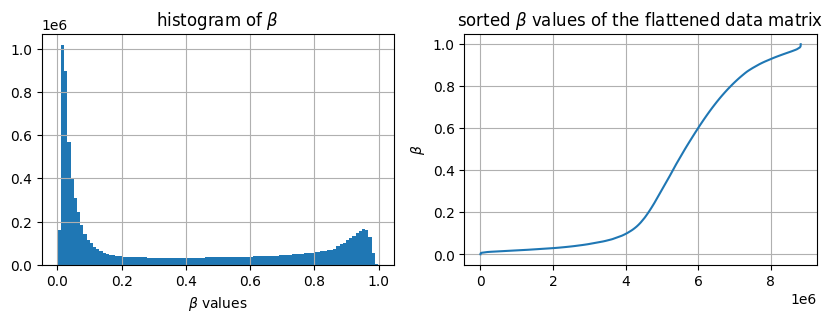

In [3]:
# HISTOGRAM ANALYSIS OF BETA VALUES

plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
plt.title('histogram of $\\beta$')
plt.hist(X_beta.ravel(),bins=100)
plt.xlabel('$\\beta$ values')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(np.sort(X_beta.ravel()))
plt.title('sorted $\\beta$ values of the flattened data matrix')
plt.ylabel('$\\beta$')
plt.grid(True)
plt.savefig('figures/histogram_betas.png', dpi=150)


# Rank normalization
To overcome this, *rank normalization* is proposed. Rank normalization maps each value of $X$ to its *rank* in the flattened matrix(*rank* = position in a sorted list of all $\beta$ values). In our case the rank is scaled to range in the interval $[0,1]$. Rank normalization has some nice properties:
- it is a monothonic transformation
- produces a flat (uniform) histogram, i.e. it equalizes the histogram

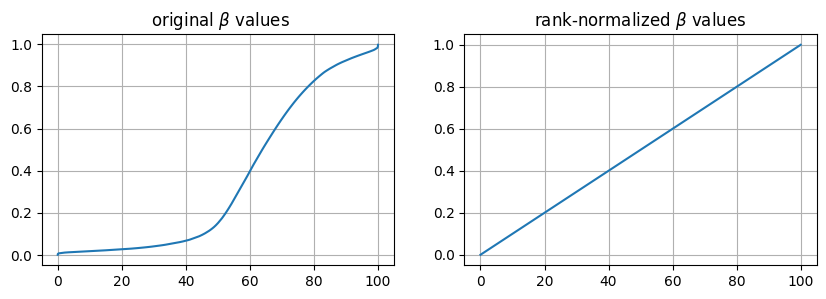

In [4]:
# get the rank for each beta value in X_beta
rank_betas = pd.DataFrame(X_beta.ravel()).rank().values

# reshape back the rank_betas array to the shape of X_beta and scale to [0,1]
X = rank_betas.reshape(X_beta.shape)/rank_betas.max()


plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(np.linspace(0,100,np.prod(X_beta.shape)),np.sort(X_beta.ravel()))
plt.title(' original $\\beta$ values')
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(np.linspace(0,100,np.prod(X.shape)),np.sort(X.ravel()))
plt.title('rank-normalized $\\beta$ values')
plt.grid(True)
plt.savefig('figures/distribution_betas_and_rank_normalized.png', dpi=150)


Now we can plot the histogram of the original $\beta$ values and the histogram of the rank-normalized $\beta$ values

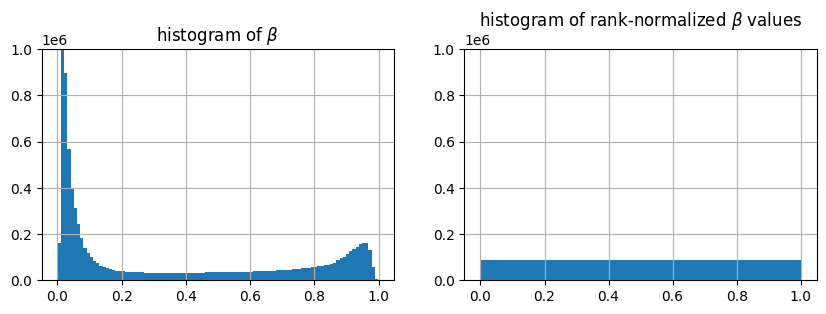

In [5]:
plt.figure(figsize=(10,3))

# original beta values
plt.subplot(1,2,1)
plt.title('histogram of $\\beta$')
plt.hist(X_beta.ravel(),bins=100)
plt.axis(ymax=1e6)
plt.grid(True)

# rank-normalized beta values
plt.subplot(1,2,2)
plt.title('histogram of rank-normalized $\\beta$ values')
plt.hist(X.ravel(),bins=100)
plt.axis(ymax=1e6)
plt.grid(True)
plt.savefig('figures/histogram_betas_and_rank_normalized.png', dpi=150)


SOM Training

In [6]:
# PARAMETERS OF THE ANALYSIS
L = 0.95                        # momentum factor for SOM learning (close to 1 is smoother)
ni,nj = (50,50)					# size of the SOM grid
n_iter = 2000					# number of epochs
batch_size = 300				# size of the minibatches

# neighborhood per epoch
nc = np.logspace(np.log10(20),np.log10(.5), n_iter)

# momentum factor per epoch
t  = np.linspace(0,1,n_iter)
lc = (1 - np.exp(-5*t))


# initialize SOM
gi,mi = inisom(X,[ni,nj])

# random initialization of SOM weights
mi_ = np.random.randn(*mi.shape)

# time statistics
before = time.time()

for i in range(n_iter):
	# minibatch of "batch_size" elements
	idx = np.random.permutation(X.shape[0])[:batch_size]
	xbatch = X[idx,:]

	L = lc[i]
	neigh = nc[i]

	# training step with the minibatch; the current SOM state is updated by the call to bsom()
	mi,mse = bsom(xbatch,gi,mi,neigh)
	# mi,mse = csom(xbatch,gi,mi,neigh)

	# "moment" smooth learning: the weights of the last minibatch are smoothly added to the general weights
	mi_ = L*mi_ + (1-L)*mi
	mi = mi_.copy()

	# show evolution (overwrite same line)
	if i%50==0:
		print(f'epoch={i}/{n_iter}  neigh={neigh:.02f}  momentum={L:.02f}  mse={mse:.02f}  dt={time.time()-before:.02f}s', end='\r')
		before = time.time()
print()  # newline after training ends


epoch=1950/2000  neigh=0.55  momentum=0.99  mse=0.22  dt=1.39s


We can now visualize the different SOM component planes for the samples

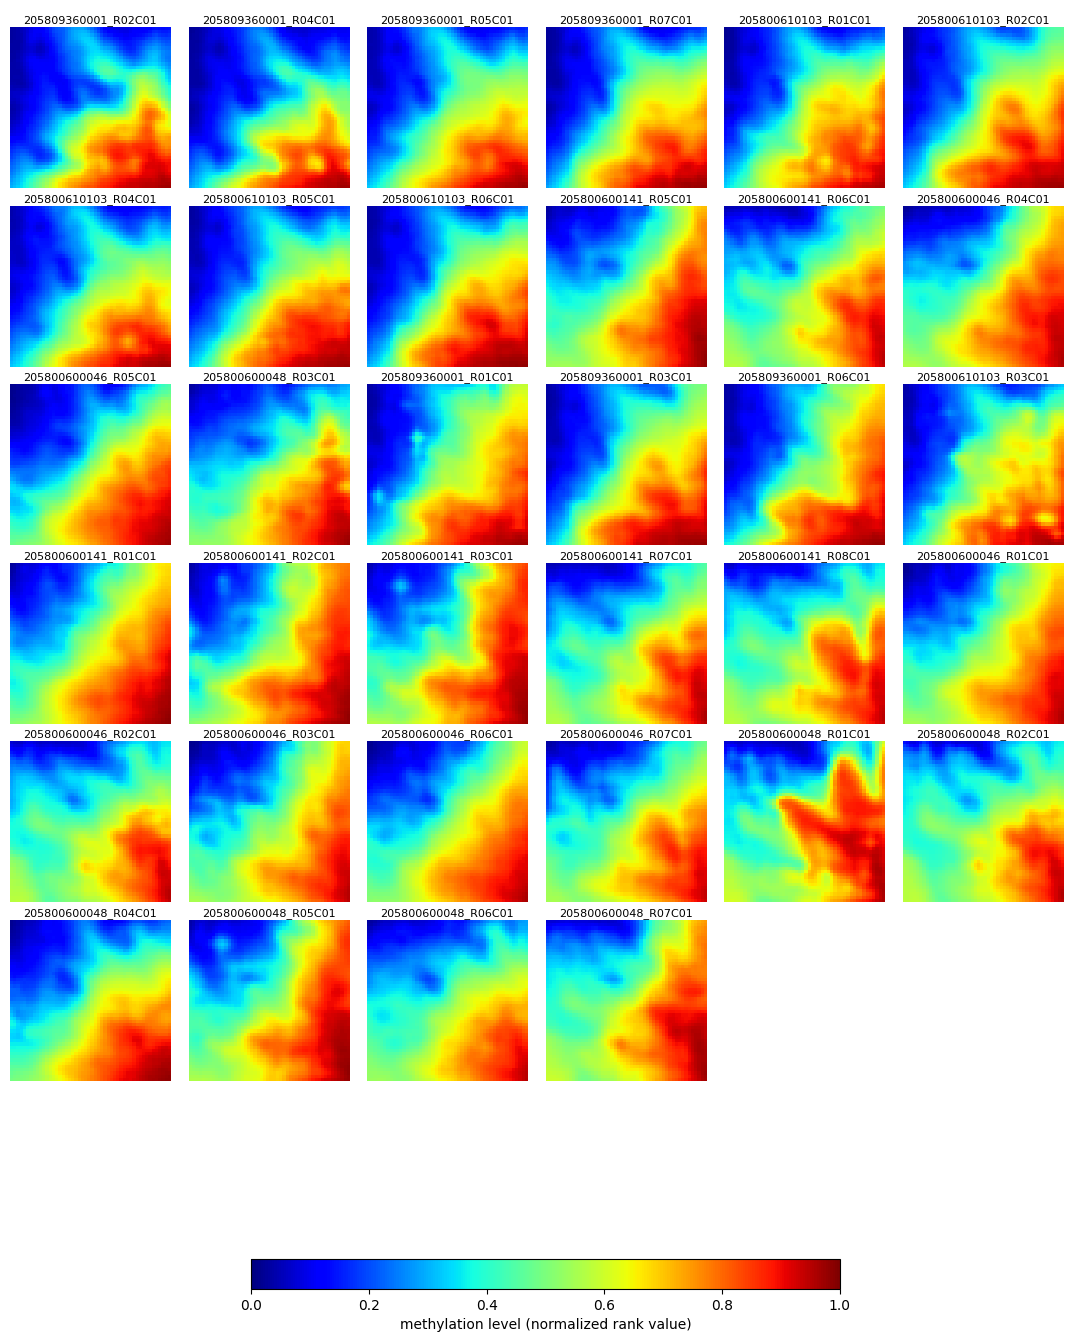

In [7]:
########################
# SOM COMPONENT PLANES
########################

colormap = 'jet'
fig = plt.figure(figsize=(15,15))
ax = fig.subplots()
[ii,jj]=np.meshgrid(np.arange(6),np.arange(6,0,-1))
pos = np.column_stack((ii.reshape(-1,1),jj.reshape(-1,1)))

for i in range(len(obs_labels)):
    img = mi[:,i].reshape(ni,nj)
    ii = pos[i,0]
    jj = pos[i,1]
    ax.imshow(img, extent=np.array([ii, ii+.9, jj, jj+.9]).ravel(), origin='lower', cmap=colormap, vmin=0, vmax=1)
    plt.text(ii+0.45,jj+.925,f'{obs_labels[i]}',fontsize=8,horizontalalignment='center')
ax.set_xlim([0,6])
ax.set_ylim([0,7])


plt.imshow(np.array([[1]]),extent=[0,0,0,0], vmin=0,vmax=1,cmap=colormap)
plt.colorbar(shrink=0.4, location='bottom', pad=0.0, label='methylation level (normalized rank value)')
plt.axis('Off')
plt.tight_layout()

plt.savefig('figures/component_planes.png', dpi=150, bbox_inches='tight')



The samples can also be projected according to their similarity using different dimensionality-reduction methods. The default option is **t-SNE**, but you can set `dr_method` to `'umap'` or `'pca'` as needed.

*Note: Results may differ along different versions of the libraries, though they should be cualitatively equivalent*

performing tsne projection of component planes


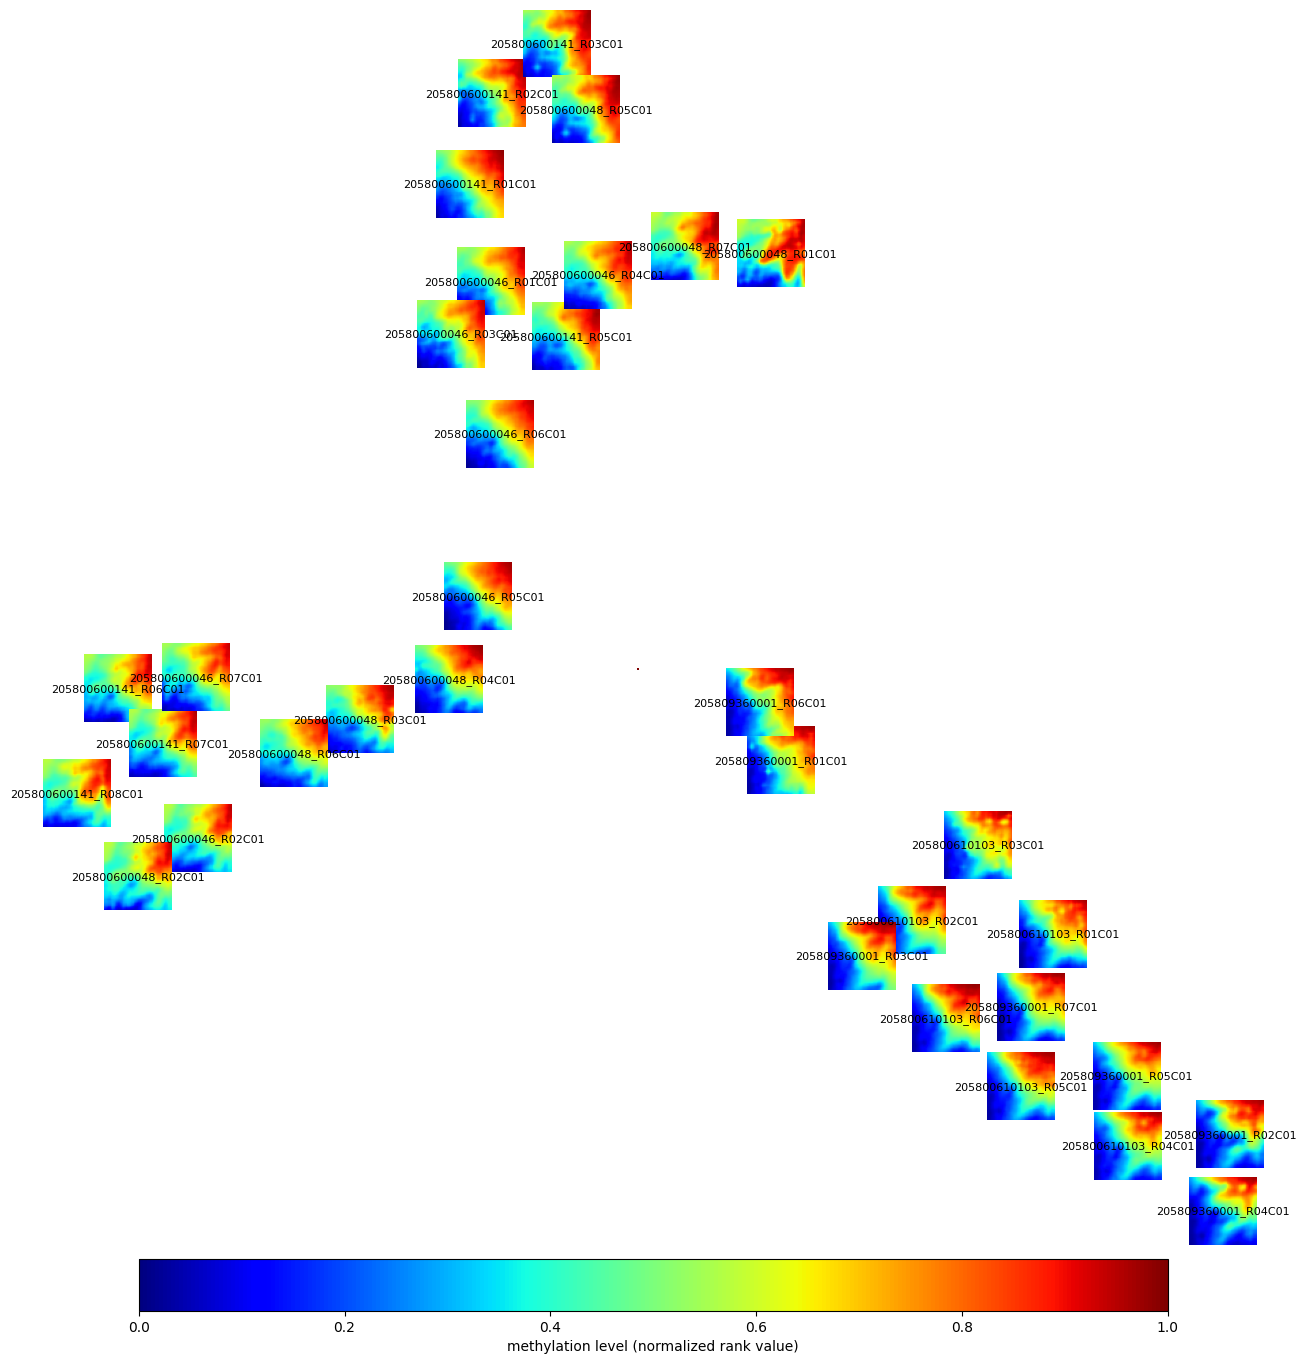

In [8]:
dr_method = 'tsne'
print('performing '+ dr_method +' projection of component planes')
if dr_method=='tsne':
    dr_map = TSNE(n_components=2, perplexity=6, random_state=42, init="random")
elif dr_method=='umap':
    dr_map = UMAP(n_components=2, min_dist=0.1, n_neighbors=5, random_state=42, init=pr)
elif dr_method=='pca':
    dr_map = PCA(n_components=2)
    
pr = dr_map.fit_transform(mi.T)
pr = StandardScaler().fit_transform(pr)*200

fig = plt.figure(figsize=(15,15))
ax = fig.subplots()
for i in range(pr.shape[0]):
    img = mi[:,i].reshape(ni,nj)
    ax.imshow(img, extent=np.array([pr[i,0]-20,pr[i,0]+20,pr[i,1]-20,pr[i,1]+20]).ravel(), origin='lower', cmap=colormap, vmin=0, vmax=1)
    plt.text(pr[i,0],pr[i,1]+2,obs_labels[i],fontsize=8,horizontalalignment='center')

plt.imshow(np.array([[1]]), vmin=0,vmax=1,cmap=colormap)
plt.colorbar(shrink=0.7, location='bottom', pad=0.01, label='methylation level (normalized rank value)')
plt.axis('Off')

# a "ghost" scatter forces the image to autoscale
ax.scatter(pr[:,0],pr[:,1],s=0)

plt.tight_layout()
plt.savefig('figures/tsne_projection.png', dpi=150, bbox_inches='tight')



## Find location of bases from specific genes
This step maps CpG sites associated with one or more genes of interest onto the trained SOM. The code below first searches the methylation table for all CpG rows whose gene annotation matches a given string, then projects those CpG profiles onto the SOM using the trained prototypes.

The resulting SOM coordinates are overlaid on top of a reference component plane, so we can visually identify the map regions where CpG sites from the selected gene family concentrate. In this example, we focus on protocadherins, which are biologically relevant in pheochromocytoma and paraganglioma and serve as one of the motivating examples in the paper.

plotting activation maps of genes matching ['PCDH'] ...
computing activation maps of genes matching ['PCDH'] ...
processing string "PCDH"


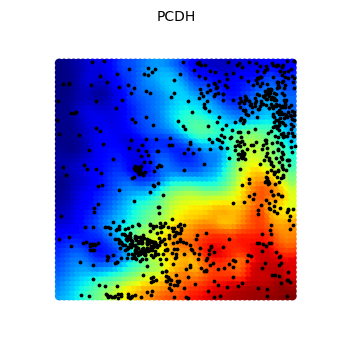

In [9]:
####################################################################
# PLOT COMPONENT PLANES WITH CpG SOM LOCATIONS OF ONE OR MORE GENES
####################################################################

# function to # compute SOM projections of all CpGs included in the list of genes of interest
def locate_genes(genes_of_interest,gi,mi):
    print(f'computing activation maps of genes matching {genes_of_interest} ...')
    # initialize the list of indices of CpG bases belonging to any gene of the list
    idx = []
    df2 = df.reset_index()
    for gen in genes_of_interest:
        print(f'processing string "{gen}"')
        #idx = idx + np.unique(np.array([gene_of_each_CpG.index(i) for i in gene_of_each_CpG if gen in str(i)])).tolist()
        idx = idx + df2[df2["UCSC_RefGene_Name"].str.contains(gen, na=False)].index.tolist()
    idx = np.array(idx)
    gendata = X[idx,:]

    # project the CpG bases belonging to the list of genes
    return fproj(gendata,gi,mi,dither=True)[2]

# list of genes of interest (those whose CpG bases we want to project)
genes_of_interest = ['PCDH'] # Get all protocadherins (start with "PCDH" in the gene name)
print(f'plotting activation maps of genes matching {genes_of_interest} ...')
n_cols = 5
n_rows = int(np.ceil(len(genes_of_interest) / n_cols))

plt.figure(figsize=(3.5 * n_cols, 3.5 * n_rows))
for i,v in enumerate(genes_of_interest):
    pr_som = locate_genes([v],gi,mi)
    plt.subplot(n_rows, n_cols, i+1)
    # sample whose SOM component plane will be visualized
    idx_obs = 0
    plt.scatter(gi[:,0],gi[:,1],s=30,c=mi[:,idx_obs],cmap=colormap)
    plt.scatter(pr_som[:,0],pr_som[:,1],s=3,c='black')
    plt.title(v,fontsize=10)
    plt.axis('Off')
    plt.axis('equal')

plt.tight_layout()
plt.savefig(f'figures/component_plane_{obs_labels[idx_obs]}.png', dpi=150, bbox_inches='tight')



This can be done for all the samples too:

PCDH, (a total of 300 CG bases)


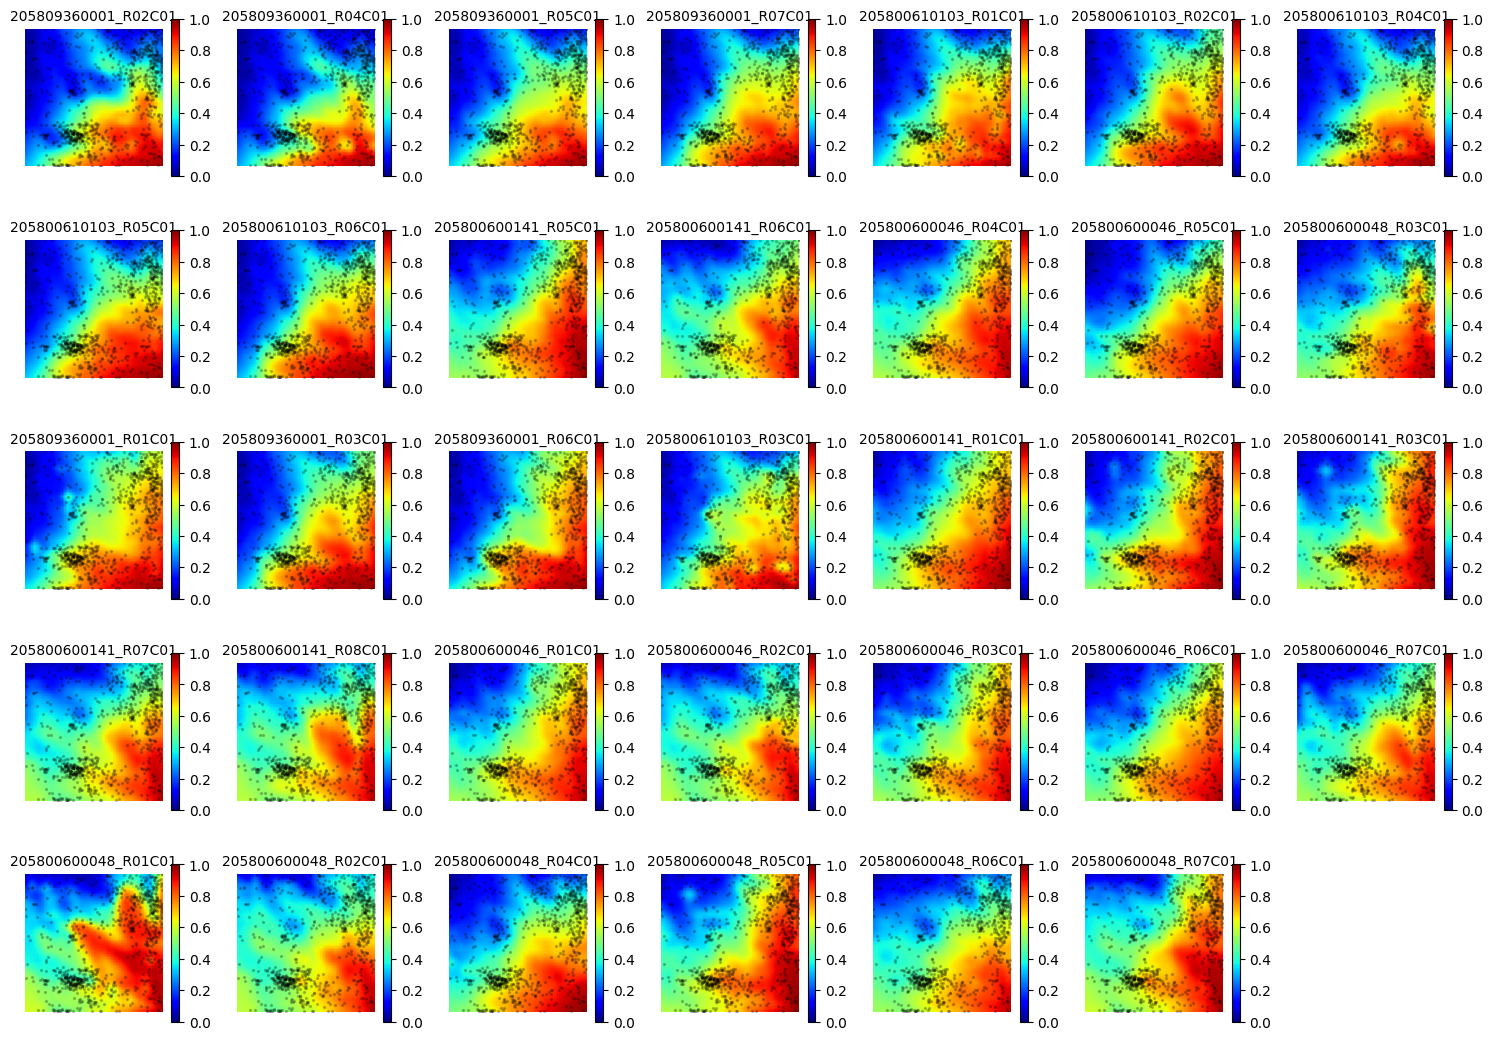

In [10]:
# VISUALIZATION OF ALL COMPONENT PLANES

fig = plt.figure(figsize=(15,15))
print(f"{''.join(genes_of_interest)}, (a total of {len(idx)} CG bases)")

for i in range(34):
    img = mi[:,i].reshape(ni,nj)
    plt.subplot(7,7,i+1)
    plt.imshow(img, origin='lower', cmap=colormap, vmin=0, vmax=1)
    plt.colorbar(shrink=0.8)
    plt.scatter(pr_som[:,0],pr_som[:,1],s=2,color='black',alpha=0.2)
    plt.title(f'{obs_labels[i]}',fontsize=10)
    plt.axis('Off')

plt.tight_layout()
plt.savefig('figures/component_planes_with_projected_genes.png', dpi=150)


## Sort SOM component planes by similarities

A 1-dimensional DR mapping can be used to map the component planes on a 1D latent space. Close projections in the latent space correspond to close samples in the input space, that is "similar" component planes. Rearranging the plotting of the component planes to match their order in the latent space results in a more readable and undestandable view of the planes

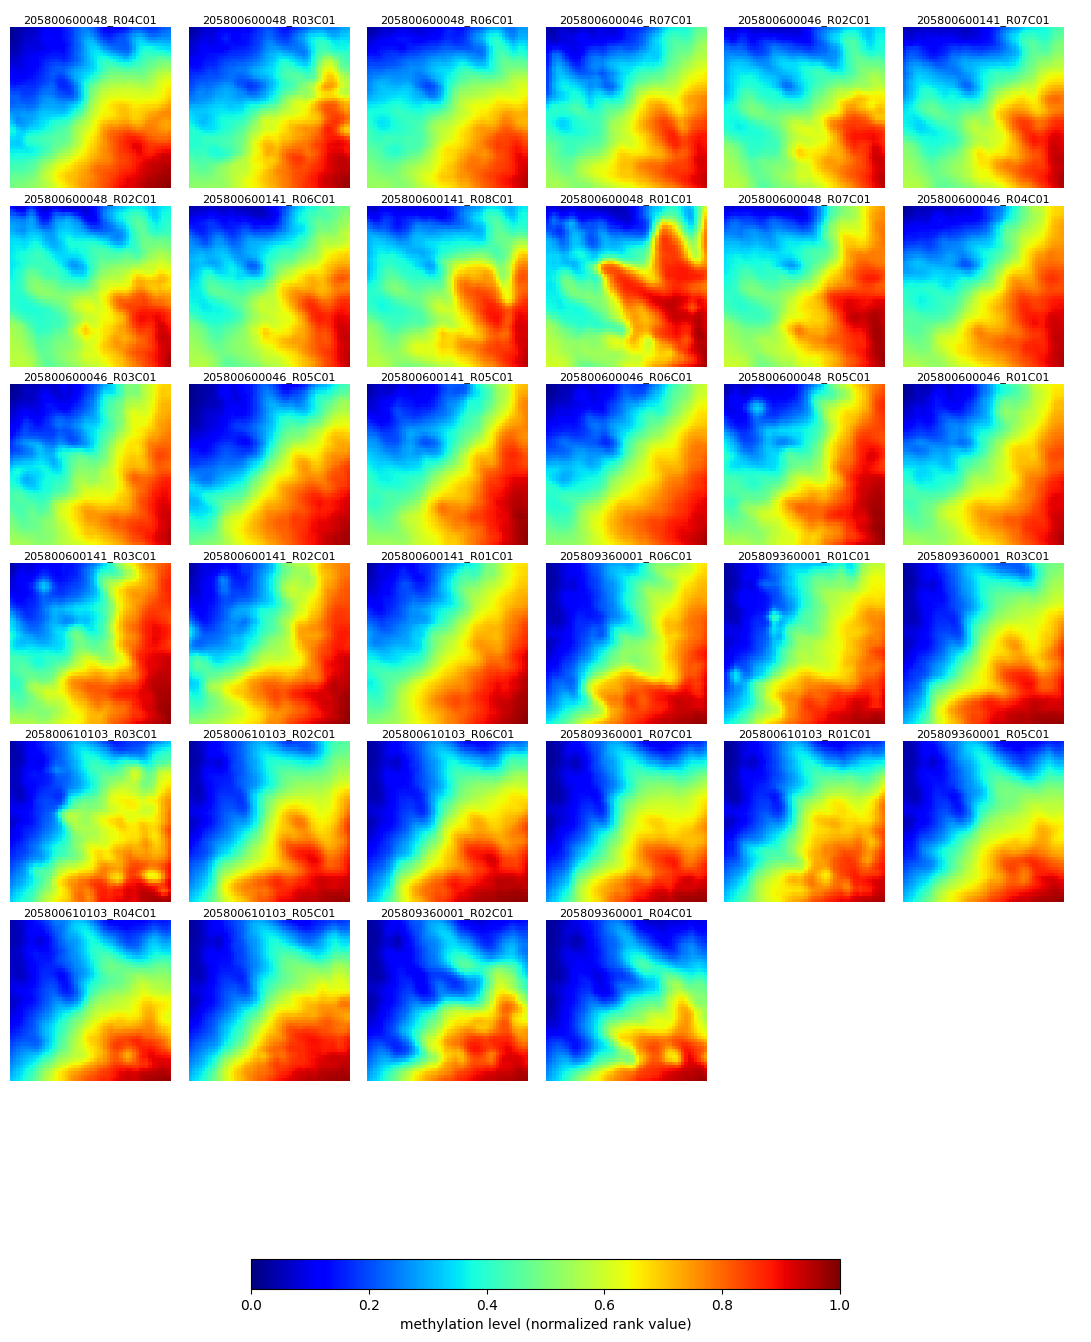

In [11]:
###############################
# SOM COMPONENT PLANES (SORTED)
###############################

# 1d arrange spatially all the samples according their similarities in methylation

dr_method = 'umap'

if dr_method=='umap':
    dr_map = UMAP(n_components=1,min_dist=0.5,n_neighbors=5)
elif dr_method=='tsne':
    dr_map = TSNE(n_components=1,perplexity=5)
elif dr_method=='pca':
    dr_map = PCA(n_components=1)

pr = dr_map.fit_transform(mi.T)
idx_sort_samples = np.argsort(pr.ravel())


colormap = 'jet'
fig = plt.figure(figsize=(15,15))
ax = fig.subplots()
[ii,jj]=np.meshgrid(np.arange(6),np.arange(6,0,-1))
pos = np.column_stack((ii.reshape(-1,1),jj.reshape(-1,1)))

# use the sorted indices instead of original ordering for the samples
for i in range(len(obs_labels)):
    i_sorted = idx_sort_samples[i]
    img = mi[:,i_sorted].reshape(ni,nj)
    ii = pos[i,0]
    jj = pos[i,1]
    ax.imshow(img, extent=np.array([ii, ii+.9, jj, jj+.9]).ravel(), origin='lower', cmap=colormap, vmin=0, vmax=1)
    plt.text(ii+0.45,jj+.925,f'{obs_labels[i_sorted]}',fontsize=8,horizontalalignment='center')
ax.set_xlim([0,6])
ax.set_ylim([0,7])


plt.imshow(np.array([[1]]),extent=[0,0,0,0], vmin=0,vmax=1,cmap=colormap)
plt.colorbar(shrink=0.4, location='bottom', pad=0.0, label='methylation level (normalized rank value)')
plt.axis('Off')
plt.tight_layout()

plt.savefig('figures/component_planes_sorted.png', dpi=150, bbox_inches='tight')


## Locating the areas dominated by selected genes

Kernel density estimation (KDE) provides a method to highlight regions occupied by CpG sites associated with specific genes. For each gene, a two-dimensional (2D) projection of all CpG sites belonging to it is computed on a self-organizing map (SOM), allowing for visualization in the SOM space. Subsequently, KDE is applied to these projections to estimate and display density per gene, facilitating comparative analysis of gene-specific spatial patterns. 

Finally, a classifier is trained using these 2D projections, with gene labels as target variables. This classifier is then evaluated across all points in a defined grid, resulting in a spatial map that reveals the dominant gene in each region. 

computing activation maps of genes matching ['PCDHGC3'] ...
processing string "PCDHGC3"
computing activation maps of genes matching ['PCDHGC4'] ...
processing string "PCDHGC4"
computing activation maps of genes matching ['PCDHGC5'] ...
processing string "PCDHGC5"


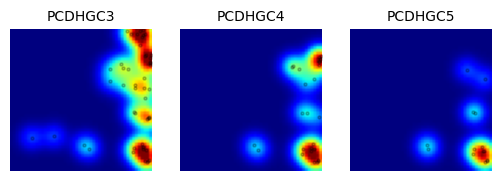

In [12]:
from sklearn.neighbors import KernelDensity
from skimage.feature import peak_local_max

genes_of_interest_2 = ['PCDHGC3', 'PCDHGC4', 'PCDHGC5']

plt.figure(figsize=(15,5))
for i,v in enumerate(genes_of_interest_2):
    pr_som = locate_genes([v],gi,mi)
    kde = KernelDensity(bandwidth=3, kernel='gaussian')
    kde.fit(pr_som)
    densities = np.exp(kde.score_samples(gi))*pr_som.shape[0]

    img = densities.reshape(ni,nj)

    plt.subplot(2,7,i+1)
    plt.imshow(img, origin='lower', cmap=colormap, vmin=0,vmax=.1)
    plt.scatter(pr_som[:,0],pr_som[:,1],s=5,color='black',alpha=0.2)


    plt.title(v,fontsize=10)
    plt.axis('Off')


## Key CpG Sites in Tumor Classification
We have a study with 34 tumor samples. Of these, we have a total of 25 labeled samples of benign and malignant tumors.

Our SOM model (*Self-Organizing Map*) has $N = n_i \times n_j$ prototypes, where each prototype represents a cluster of tens or hundreds of bases for which we have methylation values (beta values). Each prototype has 34 beta values, one for each tumor. We are interested in identifying which SOM prototypes (each representing clusters of similar CpG bases) have the most influence on differentiating between benign and malignant tumors. The influence calculated for each prototype allows us to generate a new SOM component plane, represented as a $n_i \times n_j$ image that highlights the epigenetic regions of greatest influence.

To achieve this, we perform a linear logistic regression to separate malignant from benign tumors using:

- Inputs $X_{\text{class}}$: 25 rows with $N$ beta methylation values.
- Targets $y_{\text{class}}$: 25 values, either 0 or 1 $(0 = \text{benign}, 1 = \text{malignant})$.

The logistic regression model is defined as:

$$
z = a_0 + a_1 \cdot x_1 + a_2 \cdot x_2 + \dots + a_{N} \cdot x_{N}
$$

The coefficients $a_i$ reflect the influence of each methylation value $x_i$ of prototype $i$. The $N$ $a_i$ values can be plotted on a new $n_i \times n_j$ component plane that can be compared with other component planes.


In [13]:
# 25 labeled samples with type of SDHB mutation (1=mutant, 0=wild-type)

type_of_SDHB_mutation = {
    # ----- 0 (MUT) -----
    "205809360001_R01C01": 1,
    "205809360001_R03C01": 1,
    "205800600141_R01C01": 1,
    "205800600141_R02C01": 1,
    "205800600141_R03C01": 1,
    "205800600141_R04C01": 1,
    "205800600141_R05C01": 1,
    "205800600141_R06C01": 1,
    "205800600141_R07C01": 1,
    "205800600141_R08C01": 1,

    "205800600046_R01C01": 1,
    "205800600046_R02C01": 1,
    "205800600046_R03C01": 1,
    "205800600046_R04C01": 1,
    "205800600046_R05C01": 1,
    "205800600046_R06C01": 1,
    "205800600046_R07C01": 1,
    "205800600046_R08C01": 1,

    "205800600048_R05C01": 1,
    "205800600048_R07C01": 1,
    "2058093600₀₁_R₀₆C₀₁": 1,

    # ----- 1 (WT) -----
    "205809360001_R02C01": 0,
    "205809360001_R04C01": 0,
    "205809360001_R05C01": 0,
    "205809360001_R07C01": 0,
    "205809360001_R08C01": 0,

    "205800600048_R01C01": 0,
    "205800600048_R02C01": 0,
    "205800600048_R04C01": 0,
    "205800600048_R06C01": 0,

    "205800610103_R01C01": 0,
    "205800610103_R02C01": 0,
    "205800610103_R03C01": 0,
    "205800610103_R04C01": 0,
    "205800610103_R05C01": 0,
    "205800610103_R06C01": 0,

    # ----- -1 (desconocido) -----
    #"205800600048_R03C01": -1,
}
type_labels = np.array([type_of_SDHB_mutation.get(etiqueta, np.nan) for etiqueta in obs_labels])


idxclass = [i for i,v in enumerate(type_labels) if not np.isnan(v)]
Xclass = mi[:,idxclass].T
yclass = np.array(type_labels[idxclass])


### Influence on malignancy shown on a SOM map

In this step, we aim to identify the SOM neurons (meta-sites) that contribute the most to the benign vs. malignant classification.

The workflow is:
1. Train a classifier using SOM prototypes as input features.
2. Quantify the influence of each meta-site using model coefficients (Logistic Regression).
3. Select the most influential meta-sites (highest absolute coefficients).
4. Recover the CpG sites mapped to those selected meta-sites.
5. Extract the associated genes from those CpG sites.

For the biological interpretation, we focus specifically on protocadherins, which are the gene family used in the paper to illustrate the method and its interpretability in this PPGL case study.

**Parameter tuning note (sparsity vs continuity):**
- More sparse maps: increase model complexity (e.g., higher `max_depth`, higher `learning_rate`, lower `min_samples_leaf`).
- More continuous/smooth maps: reduce model complexity (e.g., lower `max_depth`, lower `learning_rate`, higher `min_samples_leaf` and `min_samples_split`, and more `n_estimators`).

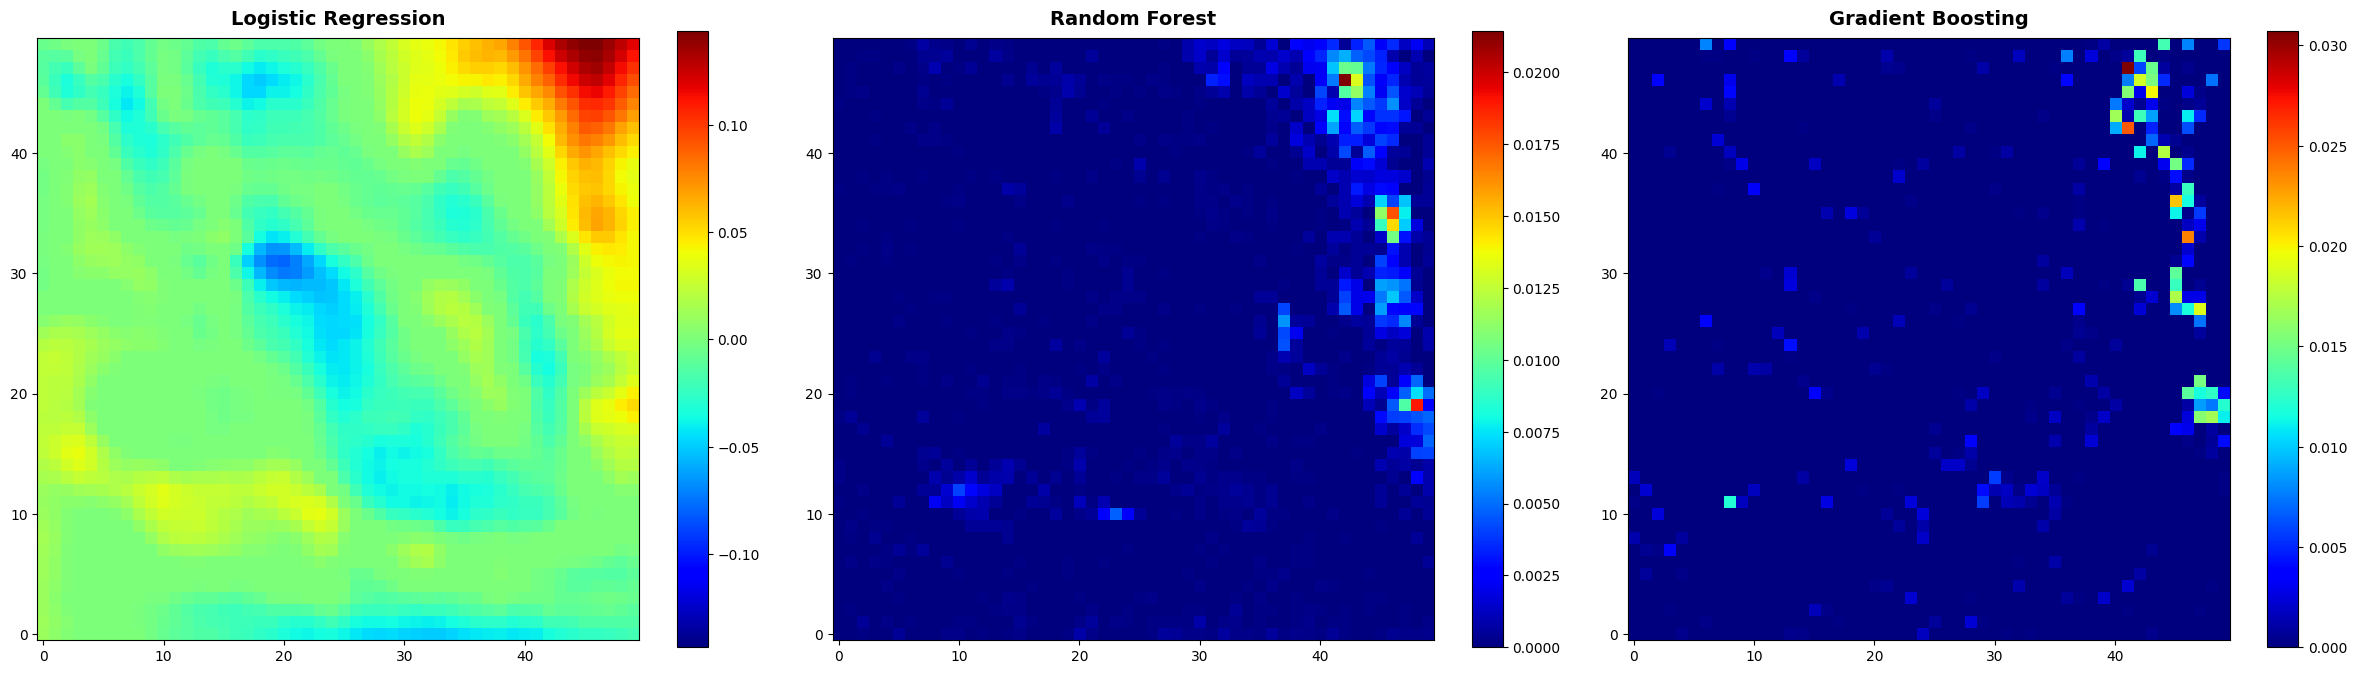

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Train a logistic regression classifier on the SOM component planes to predict the malignancy condition
classifier = LogisticRegression(C=0.5, solver='saga', l1_ratio=0.01, max_iter=5000, random_state=42)
classifier.fit(Xclass,yclass)
img_lr = classifier.coef_.reshape(ni,nj)

plt.figure(figsize=(24,8))

# Logistic Regression
plt.subplot(1,3,1)
plt.imshow(img_lr, origin='lower', cmap=colormap, vmin=-np.abs(img_lr).max(),vmax=np.abs(img_lr).max())
plt.colorbar(shrink=0.8)
plt.title('Logistic Regression', fontsize=14, fontweight='bold', pad=10)

# Random Forest classifier
classifier_rf = RandomForestClassifier(n_estimators=2000, random_state=42, max_features = 0.05)
classifier_rf.fit(Xclass, yclass)
# Get feature importances and reshape to SOM grid
img_rf = classifier_rf.feature_importances_.reshape(ni, nj)
plt.subplot(1,3,2)
plt.imshow(img_rf, origin='lower', cmap=colormap, vmin=0, vmax=img_rf.max())
plt.colorbar(shrink=0.8)
plt.title('Random Forest', fontsize=14, fontweight='bold', pad=10)

# Gradient Boosting classifier
classifier_gb = GradientBoostingClassifier(n_estimators=1200,learning_rate=0.01,max_depth=2,max_features="sqrt",random_state=42)
classifier_gb.fit(Xclass, yclass)           
img_gb = classifier_gb.feature_importances_.reshape(ni, nj)
plt.subplot(1,3,3)
plt.imshow(img_gb, origin='lower', cmap=colormap, vmin=0, vmax=img_gb.max())
plt.colorbar(shrink=0.8)
plt.title('Gradient Boosting', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()

plt.savefig('figures/classifier_importance_maps.png', dpi=150, bbox_inches='tight')

In [15]:
# Get the linear indices of the SOM grid locations using a percentile threshold on |logistic coefficients|
percentile_thr = 99.5
coef_abs = np.abs(img_lr).ravel()
thr_value = np.percentile(coef_abs, percentile_thr)
linear_idx = np.flatnonzero(coef_abs >= thr_value)

print(f"Using percentile threshold: {percentile_thr}%")
print(f"Absolute coefficient threshold value: {thr_value:.6f}")
print(f"Selected SOM neurons: {len(linear_idx)} / {coef_abs.size}")

# Compute BMU/SOM positions for all CpG rows
if 'sites_in_SOM' not in globals():
    print("Computing SOM positions for all CpG sites... this may take a while.")
    sites_in_SOM = fproj(X, gi, mi)[0]

# Indices in sites_in_SOM whose SOM location is in linear_idx
idx = np.where(np.isin(sites_in_SOM, linear_idx))[0].astype(int)

# Select elements by idx (gene_of_each_CpG is a Python list)
aux = np.asarray(gene_of_each_CpG, dtype=object)[idx]
lista = np.unique(';'.join(aux).split(';'))

# Remove uninteresting genes (those containing "LOC" or "orf") from the list
substrings = ["LOC", "orf"]
lista = sorted([str(s) for s in lista if str(s).strip() and not any(sub in str(s) for sub in substrings)])
protocadherins = [gene for gene in lista if gene.startswith("PCDH")]

# Show results, highlighting the protocadherins found in the list
print(f"Total genes found: {len(lista)}")
print(f"Protocadherins found: {len(protocadherins)}")
print("Protocadherins:")
print(",".join(protocadherins))

# You can plot the selected neurons:
# plt.scatter(gi[linear_idx, 0], gi[linear_idx, 1], s=5, color='black', alpha=0.8)
# plt.imshow(img_lr, origin='lower', cmap=colormap, vmin=-0.25, vmax=0.25)
# plt.colorbar()


Using percentile threshold: 99.5%
Absolute coefficient threshold value: 0.126774
Selected SOM neurons: 13 / 2500
Computing SOM positions for all CpG sites... this may take a while.
Total genes found: 588
Protocadherins found: 32
Protocadherins:
PCDH20,PCDHA1,PCDHA10,PCDHA11,PCDHA2,PCDHA3,PCDHA4,PCDHA5,PCDHA6,PCDHA7,PCDHA8,PCDHA9,PCDHGA1,PCDHGA10,PCDHGA11,PCDHGA12,PCDHGA2,PCDHGA3,PCDHGA4,PCDHGA5,PCDHGA6,PCDHGA7,PCDHGA8,PCDHGA9,PCDHGB1,PCDHGB2,PCDHGB3,PCDHGB4,PCDHGB5,PCDHGB6,PCDHGB7,PCDHGC3


### Ordered projection based on selected influential meta-sites

At this point, we can visualize an ordered projection of the samples again, but now using only the meta-sites selected by the logistic-regression relevance criterion (`linear_idx`).

This means the projection is no longer computed from all SOM neurons, but from the subset that is most influential for the benign vs. malignant classification. In practice, this helps reveal the sample structure driven specifically by the discriminative epigenetic signal identified in the previous step.

performing tsne projection of component planes


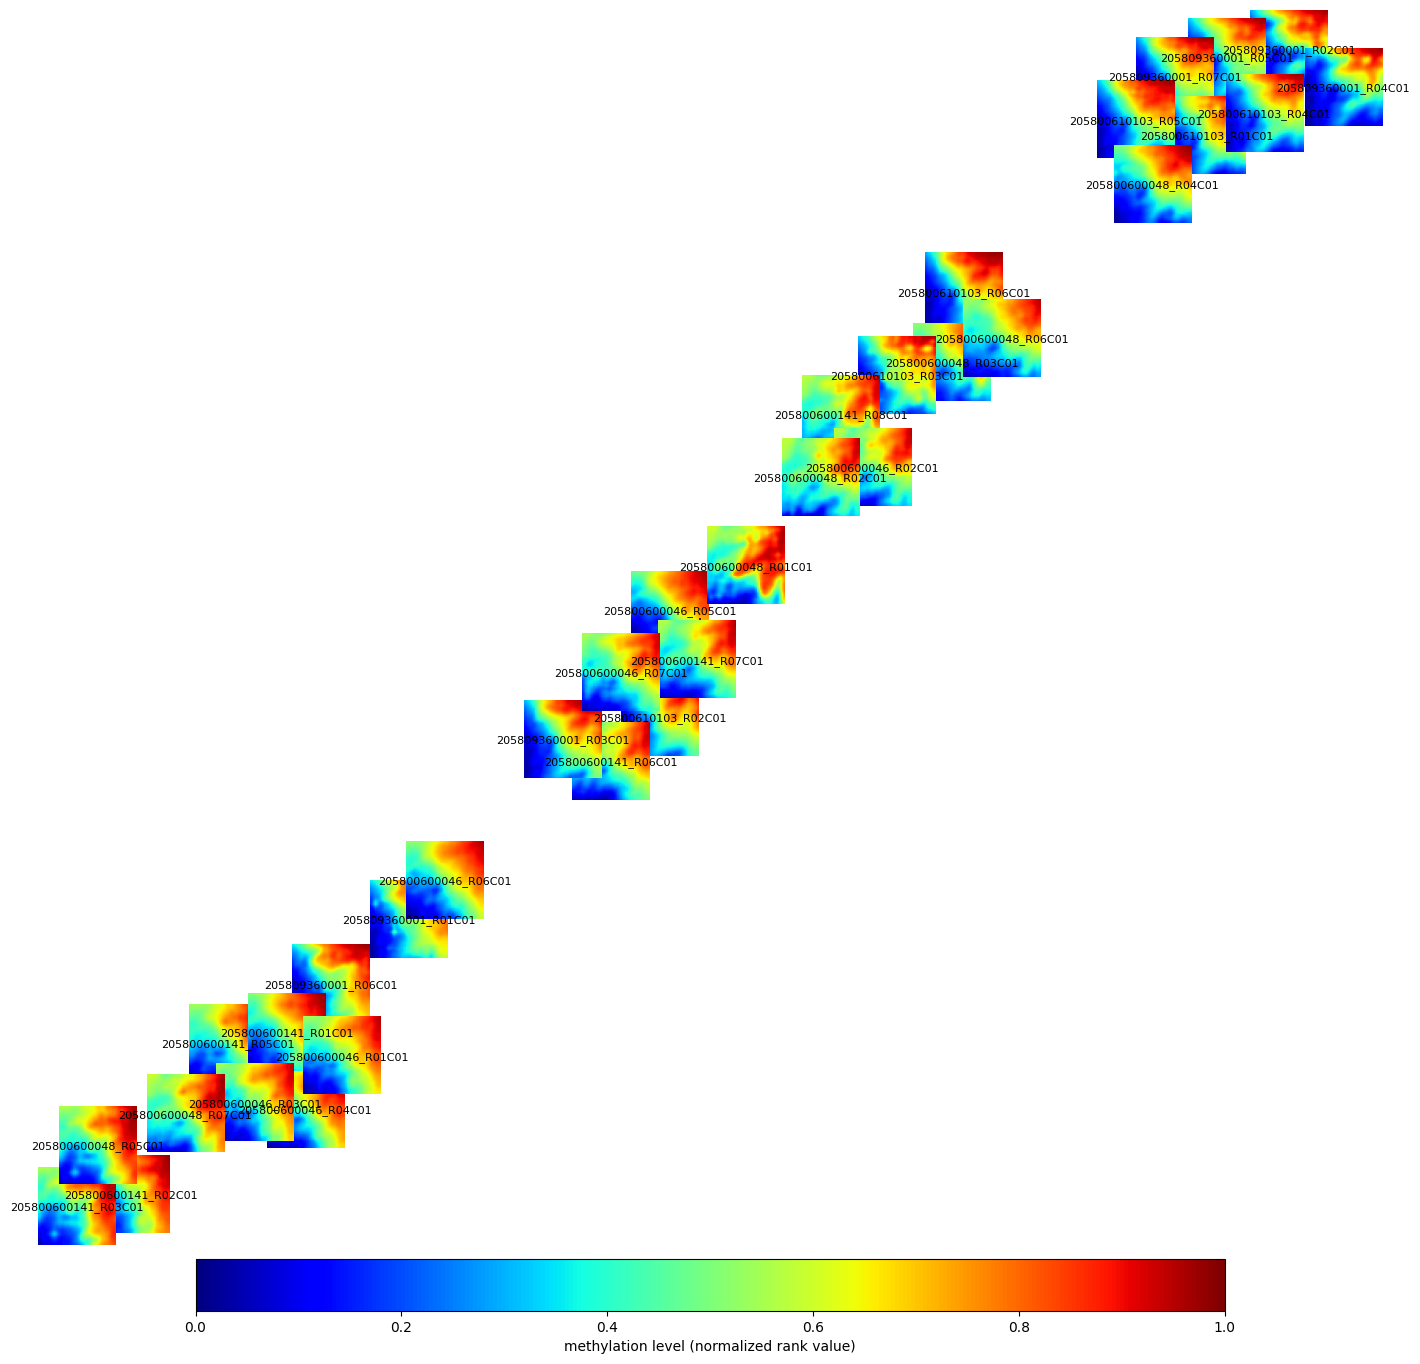

In [16]:
dr_method = 'tsne'
print('performing '+ dr_method +' projection of component planes')
if dr_method=='tsne':
    dr_map = TSNE(n_components=2, perplexity=6, random_state=42, init="pca")
elif dr_method=='umap':
    dr_map = UMAP(n_components=2, min_dist=0.1, n_neighbors=5, random_state=42, init="pca")
elif dr_method=='pca':
    dr_map = PCA(n_components=2)
    
pr = dr_map.fit_transform(mi[linear_idx].T)
pr = StandardScaler().fit_transform(pr)*200

fig = plt.figure(figsize=(15,15))
ax = fig.subplots()
for i in range(pr.shape[0]):
    img = mi[:,i].reshape(ni,nj)
    ax.imshow(img, extent=np.array([pr[i,0]-20,pr[i,0]+20,pr[i,1]-20,pr[i,1]+20]).ravel(), origin='lower', cmap=colormap, vmin=0, vmax=1)
    plt.text(pr[i,0],pr[i,1]+2,obs_labels[i],fontsize=8,horizontalalignment='center')

plt.imshow(np.array([[1]]), vmin=0,vmax=1,cmap=colormap)
plt.colorbar(shrink=0.7, location='bottom', pad=0.01, label='methylation level (normalized rank value)')
plt.axis('Off')

# a "ghost" scatter forces the image to autoscale
ax.scatter(pr[:,0],pr[:,1],s=0)

plt.tight_layout()